# Notebook 2/3 — Training

**Pipeline**: Heterogeneous RGAT for Source-Code Graph Link Prediction

This notebook:
1. Loads preprocessed artifacts from `01_preprocessing.ipynb`
2. Builds the HeteroRGATEncoder (GATv2Conv in HeteroConv) + dot-product decoder
3. Trains via masked link prediction with BCEWithLogitsLoss
4. Tracks per-relation metrics (AUC, AP, accuracy) with early stopping
5. Visualizes training curves
6. Saves the trained model checkpoint

**Prerequisites**: Run `01_preprocessing.ipynb` first to generate artifacts.

## 1. Imports & Setup

In [1]:
%pip install torch_geometric sentence-transformers igraph leidenalg --quiet

In [2]:
# ── Colab Setup ──────────────────────────────────────────────────────
import shutil, zipfile
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/MSAAI/capstone")
PROJECT_ROOT = Path("/content/rgat_project")
PROJECT_ROOT.mkdir(exist_ok=True)

# Always re-extract source code to pick up any changes
zip_src = DRIVE_DIR / "rgat_source.zip"
# Remove old source to ensure fresh extraction
for pkg in ["rgat", "graph_builder"]:
    old = PROJECT_ROOT / pkg
    if old.exists():
        shutil.rmtree(old)
with zipfile.ZipFile(zip_src, "r") as zf:
    zf.extractall(PROJECT_ROOT)
print("✓ Source code extracted (fresh)")

for d in ["artifacts", "cache", "checkpoints"]:
    (PROJECT_ROOT / d).mkdir(exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Source code extracted (fresh)
PROJECT_ROOT = /content/rgat_project


In [3]:
import sys, time, warnings, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

# PROJECT_ROOT set in Colab setup cell
sys.path.insert(0, str(PROJECT_ROOT))

# Force-reload source modules in case the kernel cached an older version
for mod_name in list(sys.modules):
    if mod_name.startswith("rgat"):
        del sys.modules[mod_name]

from rgat.config import RGATConfig
from rgat.model import HeteroRGATEncoder, RelationDecoder, LinkPredictor, SameRepoHead, DegreeBucketHead
from rgat.training import train, evaluate_link_prediction

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
print(f"PyTorch {torch.__version__}")
print(f"Artifacts: {ARTIFACTS_DIR}")

PyTorch 2.10.0+cu128
Artifacts: /content/rgat_project/artifacts


## 2. Load Preprocessed Artifacts

Load train/val HeteroData, node index, and config from the artifacts directory.

In [4]:
t0 = time.perf_counter()

# Load config
config_dict = torch.load(ARTIFACTS_DIR / "config.pt", weights_only=False)
config = RGATConfig(**config_dict)

# Override with improved hyperparameters
config.num_heads = 8
config.num_layers = 3
config.diversity_loss_weight = 1.0
config.epochs = 200
config.patience = 25

config.resolve_device()

# Load preprocessed graph data
train_data = torch.load(ARTIFACTS_DIR / "train_data.pt", weights_only=False)
val_data   = torch.load(ARTIFACTS_DIR / "val_data.pt",   weights_only=False)

# Load node index
import json
with open(ARTIFACTS_DIR / "node_index.json") as f:
    node_index = json.load(f)

load_time = time.perf_counter() - t0

print(f"Loaded in {load_time:.1f}s")
print(f"Device: {config.device}")
print(f"num_heads={config.num_heads}, num_layers={config.num_layers}, diversity_loss_weight={config.diversity_loss_weight}")
print(f"epochs={config.epochs}, patience={config.patience}")
print(f"Train edge types: {len(train_data.edge_types)}")
print(f"Val edge types  : {len(val_data.edge_types)}")
print(f"Node index types: {list(node_index.keys())}")

Loaded in 0.3s
Device: cuda
num_heads=8, num_layers=3, diversity_loss_weight=1.0
epochs=200, patience=25
Train edge types: 17
Val edge types  : 17
Node index types: ['class', 'function', 'module', 'repo']


## 3. Build Model

**Architecture (v2)**:
- **HeteroRGATEncoder**: Per-type input projection → N stacked HeteroConv layers with per-relation softmax gating + sigmoid local/global branch gate → LayerNorm + residual
- **RelationDecoder (DistMult)**: Per-triplet diagonal relation vectors — `score = (z_src * r_rel * z_dst).sum(-1)`
- **Auxiliary heads**: SameRepoHead (same-repo edge prediction), DegreeBucketHead (degree classification)
- **Diversity loss**: 3-term (head orthogonality + head variance + complementary coverage)

In [5]:
all_edge_types = list(train_data.edge_types)
all_node_types = list(config.input_dims.keys())

encoder = HeteroRGATEncoder(
    node_types=all_node_types,
    edge_types=all_edge_types,
    scalar_dims=config.scalar_dims,
    sentence_dim=config.sentence_dim,
    leiden_embed_dim=config.leiden_embed_dim,
    num_leiden_ids=config.num_leiden_ids,
    hidden_dim=config.hidden_dim,
    num_heads=config.num_heads,
    num_layers=config.num_layers,
    dropout=config.dropout,
)

# ── Decoder ──
# Identify supervised triplets for the relational decoder
supervised_triplets = [
    t for t in all_edge_types
    if t[1] in config.supervised_relations
    and hasattr(train_data[t], "edge_label_index")
]

if config.decoder_type in ("distmult", "bilinear"):
    predictor = RelationDecoder(config.hidden_dim, supervised_triplets, decoder_type=config.decoder_type)
else:
    predictor = LinkPredictor()

# ── Auxiliary heads ──
same_repo_head = SameRepoHead(config.hidden_dim) if config.aux_same_repo_weight > 0 else None
degree_head = DegreeBucketHead(config.hidden_dim, config.aux_degree_num_buckets) if config.aux_degree_weight > 0 else None

n_enc = sum(p.numel() for p in encoder.parameters())
n_pred = sum(p.numel() for p in predictor.parameters())
n_aux = sum(p.numel() for p in (same_repo_head.parameters() if same_repo_head else []))
n_aux += sum(p.numel() for p in (degree_head.parameters() if degree_head else []))

print(f"Encoder parameters : {n_enc:,}")
print(f"Decoder parameters : {n_pred:,}  (type={config.decoder_type})")
print(f"Aux head parameters: {n_aux:,}")
print(f"Total parameters   : {n_enc + n_pred + n_aux:,}")
print(f"\nSupervised triplets: {supervised_triplets}")
print(f"Same-repo head: {'enabled' if same_repo_head else 'disabled'} (weight={config.aux_same_repo_weight})")
print(f"Degree head:    {'enabled' if degree_head else 'disabled'} (weight={config.aux_degree_weight})")
print(f"\nNode types ({len(all_node_types)}): {all_node_types}")
print(f"Edge types ({len(all_edge_types)}): {len(all_edge_types)} (incl. reverse)")
print(f"\nHyperparameters:")
print(f"  hidden_dim={config.hidden_dim}, num_heads={config.num_heads}, "
      f"num_layers={config.num_layers}, dropout={config.dropout}")
print(f"  lr={config.lr}, weight_decay={config.weight_decay}, "
      f"patience={config.patience}, val_every={config.val_every}")
print(f"  diversity_loss_weight={config.diversity_loss_weight}")
print(f"  diversity: ortho={config.diversity_ortho_weight}, "
      f"var={config.diversity_variance_weight}, cov={config.diversity_coverage_weight}")

Encoder parameters : 4,236,003
Decoder parameters : 512  (type=distmult)
Aux head parameters: 8,321
Total parameters   : 4,244,836

Supervised triplets: [('class', 'INHERITS', 'class'), ('module', 'IMPORTS_MODULE', 'module'), ('function', 'CALLS', 'function'), ('function', 'CALLS', 'class')]
Same-repo head: enabled (weight=0.1)
Degree head:    disabled (weight=0.0)

Node types (4): ['class', 'function', 'module', 'repo']
Edge types (17): 17 (incl. reverse)

Hyperparameters:
  hidden_dim=128, num_heads=8, num_layers=3, dropout=0.2
  lr=0.001, weight_decay=0.0001, patience=25, val_every=5
  diversity_loss_weight=1.0
  diversity: ortho=0.5, var=0.3, cov=0.2


## 4. Training

Full-batch training with masked link prediction on the supervised edge types (CALLS, INHERITS, IMPORTS_MODULE).

Metrics reported per-relation every `val_every` epochs:
- **Loss**: BCEWithLogitsLoss
- **Accuracy**: sigmoid ≥ 0.5 threshold
- **ROC-AUC**: ranking quality metric
- **Average Precision**: precision-recall summary

Early stopping on aggregate validation AUC.

In [6]:
%%time

# Override checkpoint dir to use project root
config.checkpoint_dir = str(PROJECT_ROOT / "checkpoints")

history = train(
    encoder, predictor, train_data, val_data, config,
    same_repo_head=same_repo_head,
    degree_head=degree_head,
)

print(f"\nTraining complete.")
print(f"Epochs run: {len(history['epoch'])}")
print(f"Best val AUC: {max(history['val_auc']):.4f}")

[training] Supervised triplets: [('class', 'INHERITS', 'class'), ('module', 'IMPORTS_MODULE', 'module'), ('function', 'CALLS', 'function'), ('function', 'CALLS', 'class')]
[training] Device: cuda
[training] Decoder type: distmult
[training] Aux same-repo weight: 0.1
[training] Aux degree weight: 0.0
  Epoch    1/200 | train_loss=2.8420 | val_loss=2.8375 | val_AUC=0.5252 | val_AP=0.5756 | 8.8s
    (class, INHERITS, class): loss=0.6633  acc=0.5309  AUC=0.7459  AP=0.7476  n=2,430
    (module, IMPORTS_MODULE, module): loss=0.8397  acc=0.5000  AUC=0.1634  AP=0.3402  n=11,630
    (function, CALLS, function): loss=0.6709  acc=0.5728  AUC=0.6912  AP=0.6719  n=17,556
    (function, CALLS, class): loss=0.6635  acc=0.6328  AUC=0.7808  AP=0.7888  n=2,960
    [checkpoint] Saved best model to /content/rgat_project/checkpoints/best_model.pt
  Epoch    5/200 | train_loss=2.7017 | val_loss=2.7446 | val_AUC=0.5634 | val_AP=0.6034 | 0.7s
    (class, INHERITS, class): loss=0.6369  acc=0.6329  AUC=0.7833  

In [7]:
# Quick summary of training results
print(f"Total epochs trained: {len(history['epoch'])}")
print(f"Best val AUC: {max(history['val_auc']):.4f}")
print(f"Best val AP:  {max(history['val_ap']):.4f}")
best_auc_idx = history['val_auc'].index(max(history['val_auc']))
print(f"Best AUC at val step index: {best_auc_idx}")
print(f"\nLast 5 val AUC: {history['val_auc'][-5:]}")
print(f"Last 5 val AP:  {history['val_ap'][-5:]}")
print(f"Last 5 train loss: {[f'{x:.4f}' for x in history['train_loss'][-5:]]}")

Total epochs trained: 200
Best val AUC: 0.7715
Best val AP:  0.8027
Best AUC at val step index: 34

Last 5 val AUC: [0.7673120207370796, 0.7669157672155119, 0.7669271109316037, 0.7669853079273155, 0.7621232787698723]
Last 5 val AP:  [0.80001155413625, 0.7998876270253847, 0.800059629027941, 0.797528427123437, 0.7944525019229174]
Last 5 train loss: ['2.6364', '2.6401', '2.6281', '2.6303', '2.6304']


## 5. Training Curves

Visualize loss, AUC, and AP over training epochs.

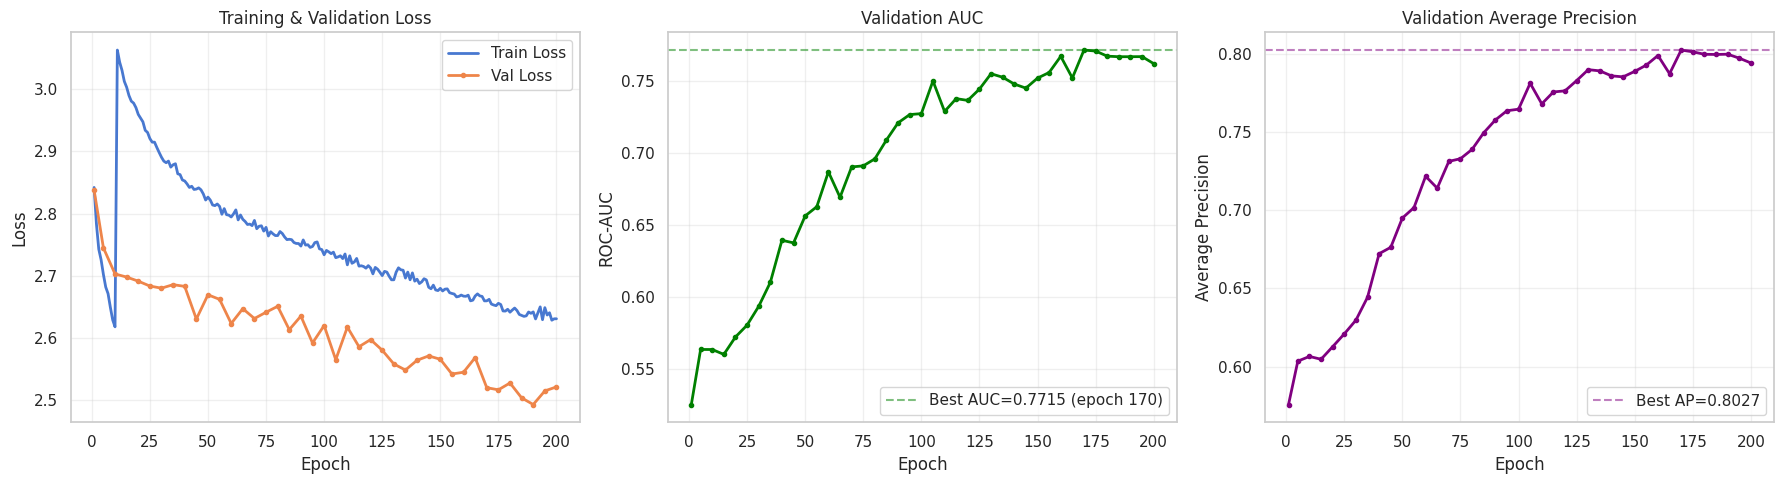

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss curve ──
ax = axes[0]
ax.plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
# val_loss is only recorded at val_every intervals; align x-axis
val_epochs = [e for e in history["epoch"] if e == 1 or e % config.val_every == 0]
ax.plot(val_epochs[:len(history["val_loss"])], history["val_loss"],
        label="Val Loss", linewidth=2, marker="o", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── AUC curve ──
ax = axes[1]
ax.plot(val_epochs[:len(history["val_auc"])], history["val_auc"],
        color="green", linewidth=2, marker="o", markersize=3)
best_auc = max(history["val_auc"])
best_epoch = val_epochs[history["val_auc"].index(best_auc)]
ax.axhline(best_auc, color="green", linestyle="--", alpha=0.5,
           label=f"Best AUC={best_auc:.4f} (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("ROC-AUC")
ax.set_title("Validation AUC")
ax.legend()
ax.grid(True, alpha=0.3)

# ── AP curve ──
ax = axes[2]
ax.plot(val_epochs[:len(history["val_ap"])], history["val_ap"],
        color="purple", linewidth=2, marker="o", markersize=3)
best_ap = max(history["val_ap"])
ax.axhline(best_ap, color="purple", linestyle="--", alpha=0.5,
           label=f"Best AP={best_ap:.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Precision")
ax.set_title("Validation Average Precision")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Training Artifacts

Save training history and confirm checkpoint was written. The best model checkpoint is automatically saved during training via early stopping.

In [ ]:
import os

# Save training history
torch.save(history, ARTIFACTS_DIR / "training_history.pt")
print(f"✓ Saved training_history.pt")

# Verify checkpoint exists
ckpt_path = PROJECT_ROOT / "checkpoints" / "best_model.pt"
if ckpt_path.exists():
    ckpt_size = os.path.getsize(ckpt_path) / 1e6
    print(f"✓ Best model checkpoint: {ckpt_path} ({ckpt_size:.1f} MB)")
else:
    print(f"⚠ Checkpoint not found at {ckpt_path}")

# Also save the encoder/predictor edge_types list for reconstruction
torch.save({
    "all_node_types": all_node_types,
    "all_edge_types": all_edge_types,
    "supervised_triplets": supervised_triplets,
}, ARTIFACTS_DIR / "model_metadata.pt")
print(f"✓ Saved model_metadata.pt")

print(f"\n→ Next: Open 03_evaluation.ipynb for final metrics and attention analysis.")

✓ Saved training_history.pt
✓ Best model checkpoint: /content/rgat_project/checkpoints/best_model.pt (17.2 MB)
✓ Saved model_metadata.pt

→ Next: Open 03_evaluation.ipynb for final metrics and attention analysis.


In [10]:
import shutil, os

# Destination on Drive — a dedicated output folder
DRIVE_OUTPUT = DRIVE_DIR / "model_output"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)

# Files to copy: (source path, destination filename)
to_copy = [
    (PROJECT_ROOT / "checkpoints" / "best_model.pt",    "best_model.pt"),
    (ARTIFACTS_DIR / "config.pt",                        "config.pt"),
    (ARTIFACTS_DIR / "model_metadata.pt",               "model_metadata.pt"),
    (ARTIFACTS_DIR / "training_history.pt",             "training_history.pt"),
    (ARTIFACTS_DIR / "node_index.json",                  "node_index.json"),
]

for src, dst_name in to_copy:
    if src.exists():
        dst = DRIVE_OUTPUT / dst_name
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f"✓ {dst_name}  →  {dst}  ({size_mb:.1f} MB)")
    else:
        print(f"⚠  {src} not found — skipping")

print(f"\nAll outputs saved to: {DRIVE_OUTPUT}")

✓ best_model.pt  →  /content/drive/MyDrive/MSAAI/capstone/model_output/best_model.pt  (17.2 MB)
✓ config.pt  →  /content/drive/MyDrive/MSAAI/capstone/model_output/config.pt  (0.0 MB)
✓ model_metadata.pt  →  /content/drive/MyDrive/MSAAI/capstone/model_output/model_metadata.pt  (0.0 MB)
✓ training_history.pt  →  /content/drive/MyDrive/MSAAI/capstone/model_output/training_history.pt  (1.1 MB)
✓ node_index.json  →  /content/drive/MyDrive/MSAAI/capstone/model_output/node_index.json  (11.1 MB)

All outputs saved to: /content/drive/MyDrive/MSAAI/capstone/model_output
